<a href="https://colab.research.google.com/github/latifahaljurayyan/insightApp/blob/main/Copy__5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
# @title
!pip install google_play_scraper

In [70]:
from google_play_scraper import reviews, Sort
import pandas as pd
import matplotlib.pyplot as plt

In [71]:
apps = {
    "Amazon": "com.amazon.mShop.android.shopping",
    "Shein": "com.zzkko",
    "AliExpress": "com.alibaba.aliexpresshd",
    "Noon": "com.noon.buyerapp",
    "Trendyol": "trendyol.com"
}


In [72]:
def label_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

In [73]:
import os
import pandas as pd
from google_play_scraper import reviews, Sort

file_path = "fixed_reviews_dataset.csv"

if os.path.exists(file_path):
    print("Loading existing dataset...")
    df = pd.read_csv(file_path)

else:
    print("Fetching reviews from Google Play...")

    all_reviews = []

    for app_name, app_id in apps.items():
        print(f"Fetching reviews for {app_name}...")

        result, _ = reviews(
            app_id,
            lang="en",
            country="us",
            sort=Sort.NEWEST,
            count=3000
        )

        for r in result:
            all_reviews.append({
                "app_name": app_name,
                "review_text": r["content"],
                "rating": r["score"],
                "sentiment_label": label_sentiment(r["score"])
            })

    df = pd.DataFrame(all_reviews)
    df.to_csv(file_path, index=False)

    print("Dataset saved successfully!")


Loading existing dataset...


In [74]:
df = pd.DataFrame(all_reviews)
df.head()


,app_name,review_text,rating,sentiment_label
0,Amazon,very good,5,Positive
1,Amazon,good,4,Positive
2,Amazon,love it 🎉🎉,5,Positive
3,Amazon,so handy,5,Positive
4,Amazon,The app was ok until recently. The new AI retu...,2,Negative


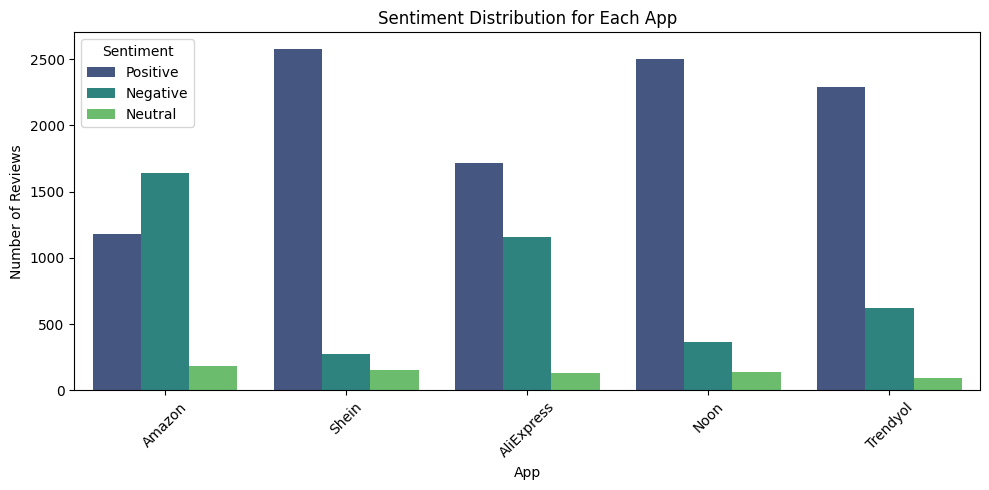

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

df_before = df.copy()
plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_before,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [76]:
print ("Before: \n", df_before["sentiment_label"]. value_counts ())

Before: 
 sentiment_label
Positive    10253
Negative     4056
Neutral       691
Name: count, dtype: int64


In [77]:
df = df[df["review_text"].astype(str).str.contains(r"[A-Za-z]", na=False)].copy()
df["review_text"] = df["review_text"].astype(str)
df = df[df["review_text"].str.strip().ne("")].copy()

print("After language/empty filtering:", len(df))

After language/empty filtering: 14437


In [78]:
import re



def clean_text(text):

    text = re.sub(r"http\S+", "", str(text))

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = text.lower()

    return text



df["clean_review"] = df["review_text"].apply(clean_text)

In [79]:
df.to_csv("google_play_app_reviews.csv", index=False)

In [80]:
df[["review_text", "clean_review"]].head(10)

,review_text,clean_review
0,very good,very good
1,good,good
2,love it 🎉🎉,love it
3,so handy,so handy
4,The app was ok until recently. The new AI retu...,the app was ok until recently the new ai retur...
5,I did not authorize this purchase. please refu...,i did not authorize this purchase please refun...
6,Continously having problems. Don't change the ...,continously having problems dont change the ap...
7,"stupid ""ai"" trying to return item asks questio...",stupid ai trying to return item asks question ...
8,never processes my payments. card has plenty o...,never processes my payments card has plenty of...
9,look at your buy stuff it works out living fro...,look at your buy stuff it works out living fro...


In [81]:
import nltk
nltk.download('punkt')
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [82]:
df["Tokens"]= df["clean_review"].apply(word_tokenize)
df[[ "clean_review","Tokens"]].head(5)

,clean_review,Tokens
0,very good,"[very, good]"
1,good,[good]
2,love it,"[love, it]"
3,so handy,"[so, handy]"
4,the app was ok until recently the new ai retur...,"[the, app, was, ok, until, recently, the, new,..."


In [83]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

r
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df["Tokens_No_Stopwords"] = df["Tokens"].apply(remove_stopwords)


def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df["Tokens_No_Stopwords_Lemmatized"] = df["Tokens_No_Stopwords"].apply(lemmatize_tokens)


df[["Tokens", "Tokens_No_Stopwords", "Tokens_No_Stopwords_Lemmatized"]].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Tokens,Tokens_No_Stopwords,Tokens_No_Stopwords_Lemmatized
0,"[very, good]",[good],[good]
1,[good],[good],[good]
2,"[love, it]",[love],[love]
3,"[so, handy]",[handy],[handy]
4,"[the, app, was, ok, until, recently, the, new,...","[app, ok, recently, new, ai, return, process, ...","[app, ok, recently, new, ai, return, process, ..."


In [84]:
df['tokens_str'] = df['Tokens_No_Stopwords_Lemmatized'].apply(lambda x: ' '.join(x))
df = df.drop_duplicates(subset='tokens_str', keep='first')

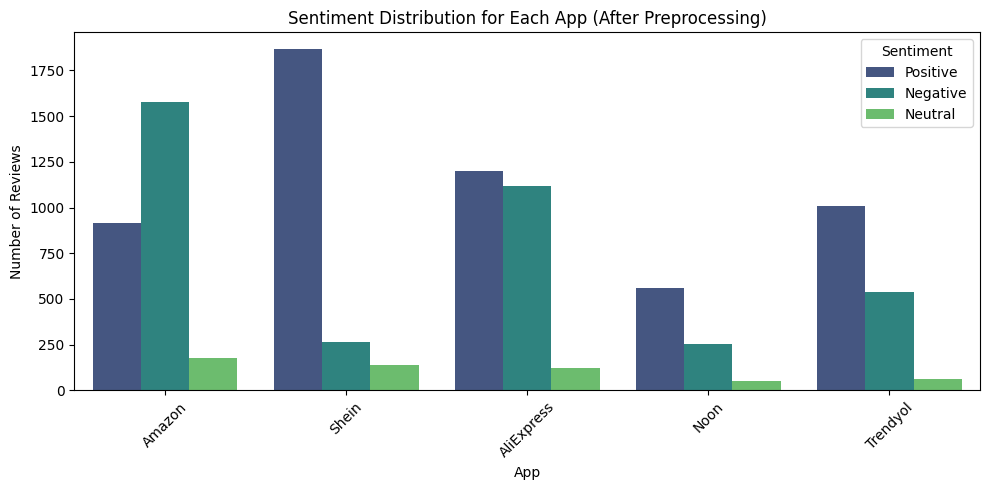

In [85]:
df_after = df.copy()

plt.figure(figsize=(10,5))

sns.countplot(
    x="app_name",
    hue="sentiment_label",
    data=df_after,
    palette="viridis"
)

plt.title("Sentiment Distribution for Each App (After Preprocessing)")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [86]:

print("\nAfter:\n", df_after["sentiment_label"].value_counts() )


After:
 sentiment_label
Positive    5551
Negative    3752
Neutral      550
Name: count, dtype: int64


In [87]:
df.to_csv("google_play_app_reviews.csv", index=False)

In [88]:
from google.colab import files
files.download("google_play_app_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
!pip install gensim

In [60]:
X_text = df['tokens_str']
y = df['sentiment_label']

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from gensim.models import Word2Vec
import numpy as np


X_train_tokens = [text.split() for text in X_train_text]
X_test_tokens = [text.split() for text in X_test_text]

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

def get_sentence_vector(tokens, model, vector_size):
  vectors = [model.wv[word] for word in tokens if word in model.wv]

  if len(vectors) ==0:
    return np.zeros(vector_size)

  return np.mean(vectors, axis=0)

X_train = np.array([get_sentence_vector(tokens, w2v_model, 100)for tokens in X_train_tokens])
X_test = np.array([get_sentence_vector(tokens, w2v_model, 100) for tokens in X_test_tokens])

In [61]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: sentiment_label
Positive    4441
Negative    3001
Neutral      440
Name: count, dtype: int64
After SMOTE: sentiment_label
Positive    4441
Negative    4441
Neutral     4441
Name: count, dtype: int64


In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_resampled, y_train_resampled)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Classification Report:\n", classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.7701674277016742
Classification Report:
               precision    recall  f1-score   support

    Negative       0.73      0.80      0.76       751
     Neutral       0.07      0.06      0.07       110
    Positive       0.87      0.82      0.84      1110

    accuracy                           0.77      1971
   macro avg       0.56      0.56      0.56      1971
weighted avg       0.77      0.77      0.77      1971



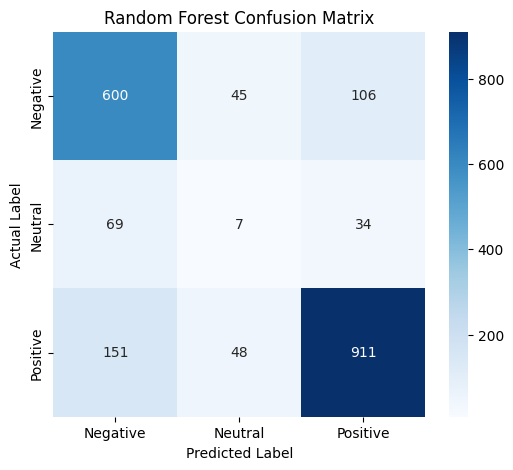

In [63]:

cm_rf = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [64]:
from sklearn.tree import DecisionTreeClassifier




dt_model = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)

dt_model.fit(X_train_resampled, y_train_resampled)


y_pred = dt_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.654490106544901

Classification Report:

              precision    recall  f1-score   support

    Negative       0.66      0.63      0.64       751
     Neutral       0.07      0.17      0.10       110
    Positive       0.81      0.72      0.76      1110

    accuracy                           0.65      1971
   macro avg       0.51      0.51      0.50      1971
weighted avg       0.71      0.65      0.68      1971

Confusion Matrix:
 [[471 135 145]
 [ 53  19  38]
 [187 123 800]]


In [65]:

from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_resampled, y_train_resampled)

y_pred_SVM = svm_model.predict(X_test)


print("SVM Accuracy:", accuracy_score(y_test, y_pred_SVM))
print("\nClassification Report:\n", classification_report(y_test, y_pred_SVM))


SVM Accuracy: 0.7275494672754946

Classification Report:
               precision    recall  f1-score   support

    Negative       0.76      0.75      0.76       751
     Neutral       0.11      0.30      0.16       110
    Positive       0.91      0.75      0.82      1110

    accuracy                           0.73      1971
   macro avg       0.59      0.60      0.58      1971
weighted avg       0.81      0.73      0.76      1971



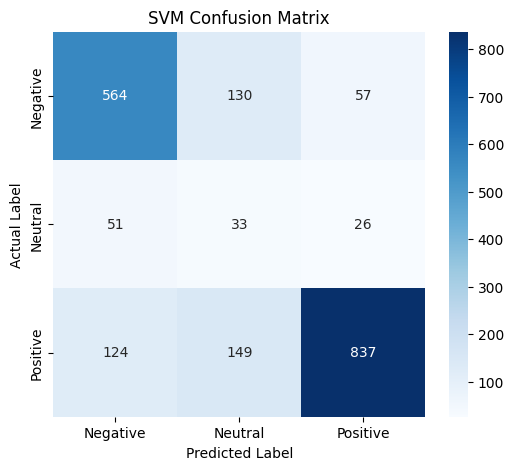

In [66]:
cm_svm = confusion_matrix(y_test, y_pred_SVM)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Confusion Matrix")
plt.show()

In [67]:
from sklearn.naive_bayes import GaussianNB


nb_model = GaussianNB()


nb_model.fit(X_train_resampled, y_train_resampled)


y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6443429731100964

Classification Report:
               precision    recall  f1-score   support

    Negative       0.69      0.81      0.75       751
     Neutral       0.06      0.20      0.10       110
    Positive       0.85      0.58      0.69      1110

    accuracy                           0.64      1971
   macro avg       0.54      0.53      0.51      1971
weighted avg       0.75      0.64      0.68      1971

Confusion Matrix:
 [[608  55  88]
 [ 66  22  22]
 [204 266 640]]


In [68]:
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder



le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)


xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train_encoded)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_encoded, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:31:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8001014713343481

Classification Report:

              precision    recall  f1-score   support

    Negative       0.75      0.80      0.78       751
     Neutral       0.25      0.01      0.02       110
    Positive       0.83      0.88      0.86      1110

    accuracy                           0.80      1971
   macro avg       0.61      0.56      0.55      1971
weighted avg       0.77      0.80      0.78      1971

Confusion Matrix:

[[601   2 148]
 [ 62   1  47]
 [134   1 975]]
